# Chapitre 5 — Modélisation Hybride

Chargement du pipeline CNN 1D + XGBoost pré-entraîné.

In [1]:
import os, sys, warnings, joblib
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sys.path.insert(0, r'c:/Users/ahoudzi/apti/aptispace-datascience-projet/src')
import pandas as pd, numpy as np
from sklearn.metrics import classification_report, roc_auc_score

PROC = r'c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed'
xgb_model = joblib.load(os.path.join(PROC, 'xgb_model.pkl'))
eval_data  = joblib.load(os.path.join(PROC, 'eval_data.pkl'))
print('Modeles charges avec succes.')
print('xgb_model type :', type(xgb_model).__name__)
print('eval_data keys  :', list(eval_data.keys()))

Modeles charges avec succes.
xgb_model type : XGBClassifier
eval_data keys  : ['y_test', 'y_pred', 'y_proba']


## Paramètres du modèle XGBoost

In [2]:
params = xgb_model.get_params()
for k, v in params.items():
    print(f'  {k:30s} : {v}')

  objective                      : binary:logistic
  base_score                     : None
  booster                        : None
  callbacks                      : None
  colsample_bylevel              : None
  colsample_bynode               : None
  colsample_bytree               : None
  device                         : None
  early_stopping_rounds          : None
  enable_categorical             : False
  eval_metric                    : auc
  feature_types                  : None
  feature_weights                : None
  gamma                          : None
  grow_policy                    : None
  importance_type                : None
  interaction_constraints        : None
  learning_rate                  : None
  max_bin                        : None
  max_cat_threshold              : None
  max_cat_to_onehot              : None
  max_delta_step                 : None
  max_depth                      : 4
  max_leaves                     : None
  min_child_weight              

## Performance sur le jeu de test

In [3]:
y_test  = eval_data['y_test']
y_pred  = eval_data['y_pred']
y_proba = eval_data['y_proba']
print(classification_report(y_test, y_pred, target_names=['Non-acheteur','Acheteur']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

Non-acheteur       0.91      0.94      0.92       381
    Acheteur       0.58      0.49      0.53        67

    accuracy                           0.87       448
   macro avg       0.75      0.71      0.73       448
weighted avg       0.86      0.87      0.87       448

AUC-ROC : 0.894


## Architecture CNN 1D (modèle pré-entraîné)

In [4]:
import pathlib
cnn_path = r'c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/cnn_extractor.keras'
size_kb = pathlib.Path(cnn_path).stat().st_size / 1024
print(f'Modele CNN : {cnn_path}')
print(f'Taille     : {size_kb:.1f} KB')
print()
print('Architecture CNN 1D :')
print('  Input  : N x 5 x 1  (AcceptedCmp1-5 tensorise)')
print('  Conv1D : 16 filtres, kernel=2, relu')
print('  Conv1D : 32 filtres, kernel=2, relu')
print('  GlobalMaxPooling1D')
print('  Dense  : 8 unites relu  -> vecteurs latents temporels')
print('  Dropout: 0.2')
print('  Output : Dense(1, sigmoid)')

Modele CNN : c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/cnn_extractor.keras
Taille     : 53.4 KB

Architecture CNN 1D :
  Input  : N x 5 x 1  (AcceptedCmp1-5 tensorise)
  Conv1D : 16 filtres, kernel=2, relu
  Conv1D : 32 filtres, kernel=2, relu
  GlobalMaxPooling1D
  Dense  : 8 unites relu  -> vecteurs latents temporels
  Dropout: 0.2
  Output : Dense(1, sigmoid)


## Top 10 des facteurs prédictifs

Features : 32 total (24 tab + 8 CNN)


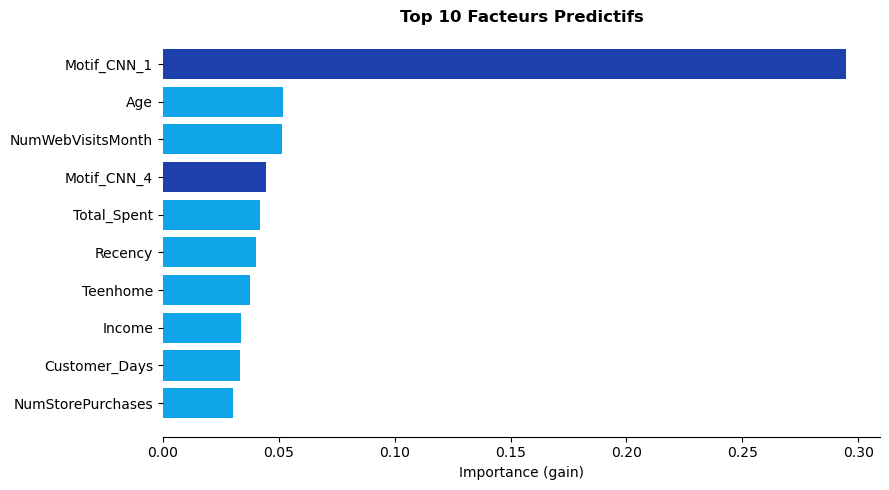

In [5]:
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
xgb_model = joblib.load('c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/xgb_model.pkl')
df = pd.read_parquet('c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/marketing_clean.parquet')
camp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
exclude = set(camp_cols + ['Response','ID','Dt_Customer','Education','Income_Strata'])
tab_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]
n_total  = len(xgb_model.feature_importances_)
n_cnn    = 8
n_tab    = n_total - n_cnn
tab_names = (tab_cols + [f'Tab_{i}' for i in range(n_tab)])[:n_tab]
feat_names = tab_names + [f'Motif_CNN_{i+1}' for i in range(n_cnn)]
imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': xgb_model.feature_importances_})
          .sort_values('Importance', ascending=False).head(10))
print(f'Features : {n_total} total ({n_tab} tab + {n_cnn} CNN)')
colors = ['#1e40af' if 'CNN' in f else '#0ea5e9' for f in imp_df['Feature']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 10 Facteurs Predictifs', fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.savefig('c:/Users/ahoudzi/apti/aptispace-datascience-projet/report/assets/importance.png', dpi=150, bbox_inches='tight')
plt.show()